In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
%load_ext autoreload
%autoreload 2
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
# pl.rc('font', family='DejaVu Sans')

%matplotlib inline
%load_ext autoreload
%autoreload 2




1 1
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from __future__ import print_function
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import os,sys
sys.path.append(os.path.abspath('/mnt/home/spandey/ceph/hmvec'))
import hmvec as hm # Git clone and pip install as in readme from github.com/msyriac/hmvec
import numpy as np
import time

cosmo_colossus = {'flat': True, 'H0': 67.66, 'Om0': 0.3111, 'Ob0': 0.0490, 'sigma8': 0.8102, 'ns': 0.9665}
h = cosmo_colossus['H0']/100
omch2 = (cosmo_colossus['Om0']-cosmo_colossus['Ob0'])*h**2
ombh2 = cosmo_colossus['Ob0']*h**2
ns = cosmo_colossus['ns']
import camb
lmax = 20000
pars = camb.CAMBparams(max_l=lmax)
pars.set_cosmology(H0=h*100,
                ombh2=ombh2,
                omch2=omch2,
                mnu=0.0,
                omk=0,
                )
pars.set_for_lmax(lmax, lens_potential_accuracy=1)
# As_fid = hcos.params['As']
As_fid = 2.1e-9
pars.InitPower.set_params(As=As_fid, ns=ns, r=0)
redshifts_all = np.linspace(0, 2, 100)
pars.set_matter_power(redshifts=redshifts_all, kmax=1000)
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)
sigma8_all = results.get_sigma8()
sigma8_camb = sigma8_all[-1]
print(f"sigma8 orig from camb is {sigma8_camb}")
As_new = As_fid*(cosmo_colossus['sigma8']/sigma8_camb)**2

cosmo_params = {'omch2': omch2,
    'ombh2': ombh2,
    'H0': cosmo_colossus['H0'],
    'ns': cosmo_colossus['ns'],
    'As': As_new
    }

zgalaxy = 0.01 # delta-function lens population
zsource = 1.0 # delta-function source population
ngal = 1e-4 # number density of lenses per mpc3 (to solve for stellar mass threshold in HOD)

# We set up the grid to integrate on
zmax = zsource + 1
numzs = 20
zs = np.linspace(0.01,zmax,numzs) # redshifts
ms = np.geomspace(2e10,1e17,100) # masses
ks = np.geomspace(5e-2,50,15) # wavenumbers

# Initialize halo model
hcos = hm.HaloModel(zs,ks,ms=ms, params=cosmo_params)
# We add an HOD which should be CMASS-like at z=zgalaxy
hcos.add_hod("g",ngal=ngal+zs*0.,corr="max")
print("Galaxy bias at zgalaxy=",zgalaxy, " is ",interp1d(zs,hcos.hods['g']['bg'])(zgalaxy))
# We add a gas profile
a = time.time()
hcos.add_battaglia_profile("electron",family="AGN",xmax=50,nxs=30000)
b = time.time()-a
print(f"Profile took {b} seconds.")

"""
Galaxy-galaxy lensing
"""
Pgn = hcos.get_power("g","nfw",verbose=False)
Pge = hcos.get_power("g","electron",verbose=False )
Pgm = hcos.total_matter_galaxy_power_spectrum(Pgn,Pge)
Pgg = hcos.get_power("g","g",verbose=False)

ns=hcos.params['ns']
Om=(hcos.params['omch2']+hcos.params['ombh2'])/hcos.h**2
Ob=(hcos.params['ombh2'])/hcos.h**2
h=hcos.h
import camb
lmax = 20000
pars = camb.CAMBparams(max_l=lmax)
pars.set_cosmology(H0=h*100,
                ombh2=Ob * h ** 2,
                omch2=(Om - Ob) * h ** 2,
                mnu=0.0,
                omk=0,
                )
pars.set_for_lmax(lmax, lens_potential_accuracy=1)
As_fid = hcos.params['As']
pars.InitPower.set_params(As=As_fid, ns=ns, r=0)
redshifts_all = np.linspace(0, 2, 100)
pars.set_matter_power(redshifts=redshifts_all, kmax=1000)
pars.NonLinear = camb.model.NonLinear_none
results = camb.get_results(pars)
sigma8_all = results.get_sigma8()
sigma8_camb = sigma8_all[-1]
print(f"sigma8 from camb is {sigma8_camb}")



Note: redshifts have been re-sorted (earliest first)
sigma8 orig from camb is 0.82385211419817
Bisection search converged in  19  iterations.
Galaxy bias at zgalaxy= 0.01  is  1.5577055047727684


/mnt/home/spandey/ceph/hmvec/hmvec/hmvec.py:719: RuntimeWarning: invalid value encountered in divide
  ret = Ns**2./Nc
/mnt/home/spandey/ceph/hmvec/hmvec/fft.py:91: RuntimeWarning: invalid value encountered in divide
  uk = ukts/kts[None,None,:]/mnorm[...,None]


Profile took 2.9714834690093994 seconds.
Note: redshifts have been re-sorted (earliest first)
sigma8 from camb is 0.8102


In [3]:
Cl_cmb = results.get_cmb_power_spectra(pars, lmax=lmax, CMB_unit='muK', raw_cl=True)['total'][:,0]
ell_cmb = np.arange(Cl_cmb.shape[0])

df = np.loadtxt(abs_path_data + '/pge/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt')
# df.shape
ell_noise = df[:,0]
Nell_T = df[:,1]
Nell_interp = interp1d(np.log(ell_noise),np.log(np.clip(Nell_T, 1e-10, 1e10)),bounds_error=False,fill_value='extrapolate')
Nell_T = np.exp(Nell_interp(np.log(ell_cmb)))
Nell_T[0] = Nell_T[1]

df_ksz = np.loadtxt(abs_path_data + '/pge/ksz_autopower_webksky_muK2.txt')
ell_ksz = df_ksz[:,0]
Cl_ksz = df_ksz[:,1]
# Cl_ksz[0] = Cl_ksz[1]
# print(Cl_ksz)

Cl_ksz_interp = interp1d(np.log(ell_ksz),np.log(np.clip(Cl_ksz, 1e-20, 1e20)),bounds_error=False,fill_value='extrapolate')
Cl_ksz = np.exp(Cl_ksz_interp(np.log(ell_cmb)))
Cl_ksz[0] = 1e-30
Cl_ksz[1] = 1e-30


Cl_tot = Cl_cmb + Nell_T + Cl_ksz



/tmp/ipykernel_1142280/3505927359.py:9: RuntimeWarning: divide by zero encountered in log
  Nell_T = np.exp(Nell_interp(np.log(ell_cmb)))
/tmp/ipykernel_1142280/3505927359.py:18: RuntimeWarning: divide by zero encountered in log
  Cl_ksz_interp = interp1d(np.log(ell_ksz),np.log(np.clip(Cl_ksz, 1e-20, 1e20)),bounds_error=False,fill_value='extrapolate')
/tmp/ipykernel_1142280/3505927359.py:19: RuntimeWarning: divide by zero encountered in log
  Cl_ksz = np.exp(Cl_ksz_interp(np.log(ell_cmb)))
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in subtract
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [4]:
# Nell_T
# Cl_cmb
# Cl_ksz
Cl_tot

array([1.03232316e-04, 1.03232316e-04, 1.04174386e+03, ...,
       1.46504751e-04, 1.46518324e-04, 1.46531898e-04])

(1e-11, 100)

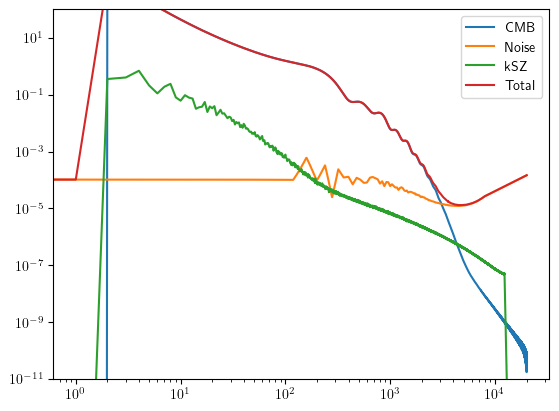

In [5]:
pl.figure()
pl.loglog(ell_cmb,Cl_cmb,label='CMB')
pl.loglog(ell_cmb,Nell_T,label='Noise')
pl.loglog(ell_cmb,Cl_ksz,label='kSZ')
pl.loglog(ell_cmb,Cl_tot,label='Total')
pl.legend()
pl.ylim(1e-11, 100)



In [6]:
zedges = np.array([0.4, 0.6, 0.8,1.1])
Ngals_bins = 3.33*np.array([506905, 771875, 859824])
Ngals_tot = np.sum(Ngals_bins)
Vol_Gpc3 = (14000/5840)*np.array([2.6, 4.0, 5.0])
z_cens = np.array([0.51, 0.71, 0.92])
Vol_Mpc3 = Vol_Gpc3*1e9
ngal_mpc3 = Ngals_bins/Vol_Mpc3

from hmvec import ksz
ksz_obj = ksz.kSZ(z_cens, Vol_Gpc3, ngal_mpc3,engine='camb')

logkcens = np.log(ks)
dlogk = logkcens[1]-logkcens[0]
logk_edges = logkcens - dlogk/2
logk_edges = np.append(logk_edges,logk_edges[-1]+dlogk)
ks_bin_edges = np.exp(logk_edges)

# hmvec gives results in Mpc, we need Mpc/h units
Pge_err_z0 = np.nan_to_num(ksz_obj.Pge_err(0,ks_bin_edges,Cl_tot), nan=1e5, posinf=1e5, neginf=1e5)
Pge_err_z1 = np.nan_to_num(ksz_obj.Pge_err(1,ks_bin_edges,Cl_tot), nan=1e5, posinf=1e5, neginf=1e5)
Pge_err_z2 = np.nan_to_num(ksz_obj.Pge_err(2,ks_bin_edges,Cl_tot), nan=1e5, posinf=1e5, neginf=1e5)

# ks were in Mpc, convert to h/Mpc:
Pge_err_z0_interp = interp1d(np.log(ks),np.log(Pge_err_z0),bounds_error=False,fill_value='extrapolate')
Pge_err_z1_interp = interp1d(np.log(ks),np.log(Pge_err_z1),bounds_error=False,fill_value='extrapolate')
Pge_err_z2_interp = interp1d(np.log(ks),np.log(Pge_err_z2),bounds_error=False,fill_value='extrapolate')

h = cosmo_colossus['H0']/100
ks_wh = ks / h
Pge_err_z0_wh = np.exp(Pge_err_z0_interp(np.log(ks_wh))) * h**3
Pge_err_z1_wh = np.exp(Pge_err_z1_interp(np.log(ks_wh))) * h**3
Pge_err_z2_wh = np.exp(Pge_err_z2_interp(np.log(ks_wh))) * h**3


/mnt/home/spandey/ceph/hmvec/hmvec/fft.py:91: RuntimeWarning: invalid value encountered in divide
  uk = ukts/kts[None,None,:]/mnorm[...,None]
/mnt/home/spandey/ceph/hmvec/hmvec/hmvec.py:719: RuntimeWarning: invalid value encountered in divide
  ret = Ns**2./Nc


Bisection search converged in  18  iterations.


/mnt/home/spandey/ceph/hmvec/hmvec/ksz.py:170: UserWarning: Using equal k_min at each z, despite different volumes at each z
  warnings.warn('Using equal k_min at each z, despite different volumes at each z')


Note: redshifts have been re-sorted (earliest first)


/mnt/home/spandey/ceph/hmvec/hmvec/ksz.py:56: RuntimeWarning: divide by zero encountered in power
  return (volume * kstar**2 / 12 / np.pi**3 / chistar**2. * pgv_int * np.asarray(ints))**(-0.5)


In [7]:
# h = 
# ks_wh
Pge_err_z0



array([1.00000000e+05, 1.80528546e+05, 2.85052829e+04, 7.26290175e+03,
       2.62716449e+03, 6.91000907e+02, 1.16547184e+02, 1.95930864e+01,
       9.30546736e+00, 8.85271697e+00, 8.15452494e+00, 1.78056486e+01,
       1.00000000e+05, 1.00000000e+05, 1.00000000e+05])

(0.1, 10)

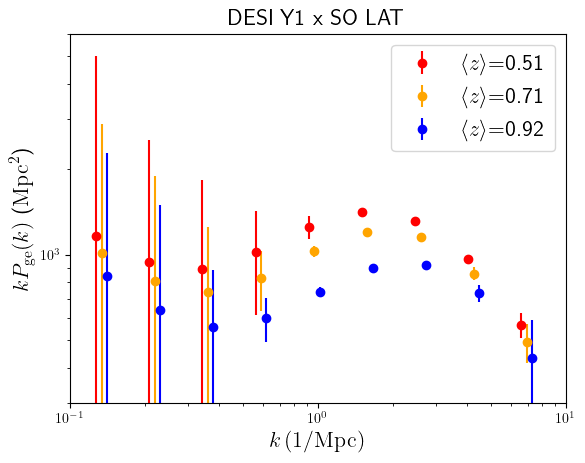

In [8]:
pl.rc('text', usetex=True)
from matplotlib import cm, colorbar
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
dsfac = 1
indz = np.argmin(np.abs(zs - z_cens[0]))
pl.errorbar(0.95*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z0)[::dsfac],label=r'$\langle z \rangle$=0.51', color='red', ls='', marker='o')

indz = np.argmin(np.abs(zs - z_cens[1]))
pl.errorbar(ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z1)[::dsfac],label=r'$\langle z \rangle$=0.71', color='orange', ls='', marker='o')

indz = np.argmin(np.abs(zs - z_cens[2]))
pl.errorbar(1.05*ks[::dsfac],(ks*Pge[indz])[::dsfac], (ks*Pge_err_z2)[::dsfac],label=r'$\langle z \rangle$=0.92', color='blue', ls='', marker='o')

pl.title('DESI Y1 x SO LAT', fontsize=16)
pl.ylim(3e2, 6e3)
pl.legend(fontsize=16)
pl.xscale('log')
pl.yscale('log')
pl.xlabel(r'$k \,  (1/{\rm Mpc})$', fontsize=16)
pl.ylabel(r'$kP_{\rm ge}(k)$ (${\rm Mpc}^2$)', fontsize=16)
pl.xlim(0.1, 10)





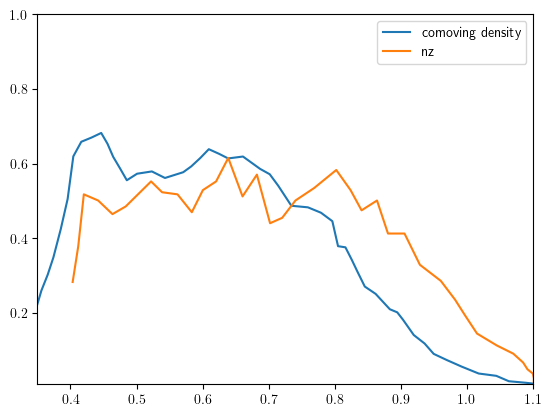

In [9]:
df1 = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/pge/desi_lrg_comoving_density.txt')
df2 = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/pge/desi_lrg_nz.txt')
# df1.shape, df2.shape
pl.figure()
pl.plot(df1[:,0], df1[:,1], label='comoving density')
pl.plot(df2[:,0], 1e3*df2[:,1], label='nz')
# pl.yscale('log')
pl.ylim(1e-2, 1)
pl.xlim(0.35, 1.1)
pl.legend()


In [10]:
from scipy.interpolate import interp1d
ks = np.geomspace(5e-2,50,15) # wavenumbers
ks_wh = ks / h

zedges = np.array([0.4, 0.6, 0.8,1.1])
Ngals_bins = 3.33*np.array([506905, 771875, 859824])
Ngals_tot = np.sum(Ngals_bins)
# Vol_Gpc3 = (14000/5840)*np.array([2.6, 4.0, 5.0])
# z_cens = np.array([0.51, 0.71, 0.92])
# Vol_Mpc3 = Vol_Gpc3*1e9
# ngal_mpc3 = Ngals_bins/Vol_Mpc3


zedges = np.array([0.4, 0.6, 0.8,1.1])
nz_lrg_all = np.loadtxt(abs_path_data + '/pge/desi_lrg_nz.txt')
# nz_lrg_all.shape
zv, nzv = nz_lrg_all[:,0], nz_lrg_all[:,1]


nbins_lens = len(zedges) - 1
zarray_lens = np.linspace(0.001, 1.6, 100)
nz_interp = interp1d(zv, nzv, fill_value=1e-10, bounds_error=False)
nz_zarray = nz_interp(zarray_lens)
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb


df_nz_comoving = np.loadtxt('/mnt/home/spandey/ceph/GODMAX/data/pge/desi_lrg_comoving_density.txt')
    
zarray_comoving = df_nz_comoving[:,0]
nz_comoving = df_nz_comoving[:,1]



In [ ]:
# cosmo_params_dict = {'flat': True, 'H0': 70.0, 'Om0': 0.2793, 'Ob0': 0.0463, 'sigma8': 0.821, 'ns': 0.972, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.31, 'Ob0': 0.049, 'sigma8': 0.81, 'ns': 0.95, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.3136, 'Ob0': 0.0491, 'sigma8': 0.8416941, 'ns': 0.9645, 'w0':-1.0}
# cosmo_colossus = {'flat': True, 'H0': 67.66, 'Om0': 0.3111, 'Ob0': 0.0490, 'sigma8': 0.8102, 'ns': 0.9665}
cosmo_params_dict = {'flat': True, 'H0': 67.66, 'Om0': 0.3111, 'Ob0': 0.0490, 'sigma8': 0.8102, 'ns': 0.9665, 'w0':-1.0}
# cosmo_params_dict = {'flat': True, 'H0': 67.2, 'Om0': 0.29, 'Ob0': 0.049, 'sigma8': 0.783, 'ns': 0.95, 'w0':-1.0}
sim_params_dict = {}
sim_params_dict['nfw_trunc'] = True
# sim_params_dict['gamma_rhogas'] = 2.0
# sim_params_dict['delta_rhogas'] = 7.0

sim_params_dict['gamma_rhogas'] = 1.2
sim_params_dict['delta_rhogas'] = 6.0


sim_params_dict['theta_co_0'] = 0.01
sim_params_dict['log10_Mstar0_theta_co'] = 15.0
sim_params_dict['nu_theta_co_M'] = 0.0
sim_params_dict['nu_theta_co_z'] = 0.0

sim_params_dict['theta_ej_0'] = 3.0
sim_params_dict['log10_Mstar0_theta_ej'] = 15.0
sim_params_dict['nu_theta_ej_M'] = 0.0
sim_params_dict['nu_theta_ej_z'] = 0.0

sim_params_dict['log10_Mc0'] = 14.38
sim_params_dict['log10_Mstar0'] = 14.0
sim_params_dict['mu_beta'] = 0.6
sim_params_dict['nu_z'] = 0.0
sim_params_dict['nu_M'] = 0.0

sim_params_dict['eta_star'] = 0.3
sim_params_dict['eta_cga'] = 0.6


sim_params_dict['neg_bhse_plus_1'] = 0.833
sim_params_dict['A_starcga'] = 0.09
sim_params_dict['log10_M1_starcga'] = 11.4
sim_params_dict['epsilon_rt'] = 4.0


sim_params_dict['a_zeta'] = 0.3
sim_params_dict['n_zeta'] = 2
sim_params_dict['alpha_nt'] = 0.18
sim_params_dict['beta_nt'] = 0.5
sim_params_dict['n_nt'] = 0.3
sim_params_dict['cosmo'] = cosmo_params_dict

# hod_params_dict = {}
# hod_params_dict['logMmin'] = 12.88
# hod_params_dict['sigma_logM'] = 0.2
# hod_params_dict['logM0'] = 12.88
# hod_params_dict['logM1'] = 14.0
# hod_params_dict['alpha'] = 1.3
# sim_params_dict['hod_params'] = hod_params_dict
# sim_params_dict['hod_type'] = 'Zheng05'

sim_params_dict['log10M1_fshmr'] = 12.35
sim_params_dict['log10Mstar0_fshmr'] = 10.72
sim_params_dict['beta_fshmr'] = 0.44
sim_params_dict['delta_fshmr'] = 0.57
sim_params_dict['gamma_fshmr'] = 1.56
sim_params_dict['Bcut_Nsat'] = 1.69
sim_params_dict['Bsat_Nsat'] = 9.01
sim_params_dict['betacut_Nsat'] = 0.6
sim_params_dict['betasat_Nsat'] = 0.74
sim_params_dict['alphasat_Nsat'] = 1.0
sim_params_dict['siglogMstar_Ncen'] = 0.25

sim_params_dict['nbar_gal_comoving_zarray'] = zarray_comoving
sim_params_dict['nbar_gal_comoving_val'] = nz_comoving

halo_params_dict = {}
halo_params_dict['rmin'], halo_params_dict['rmax'], halo_params_dict['nr'] = 5e-3, 8, 32
halo_params_dict['zmin'], halo_params_dict['zmax'], halo_params_dict['nz'] = 0.01, 2.0, 22
halo_params_dict['lg10_Mmin'], halo_params_dict['lg10_Mmax'], halo_params_dict['nM'] = 11.0, 16.0, 24
# halo_params_dict['cmin'], halo_params_dict['cmax'], halo_params_dict['nc'] = 2, 9, 16

lmin = 10.0
lmax = 11000.0
fac = 1
dl_log_array = 0.23025851 / fac
# dl_log_array = 0.1
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
halo_params_dict['nell'] = len(l_array_survey)
halo_params_dict['ellmin'] = l_array_survey[0]
halo_params_dict['ellmax'] = l_array_survey[-1]
# halo_params_dict['ellmin'], halo_params_dict['ellmax'], halo_params_dict['nell'] = 8, 2**14, 32
# try:
halo_params_dict['sig_logc_z_array'] = np.ones(halo_params_dict['nz']) * 0.05
halo_params_dict['mdef'] = '200c'
halo_params_dict['hmf_model'] = 'T10'
# halo_params_dict['conc_model'] = 'Diemer15'
halo_params_dict['conc_model'] = 'Duffy08'
halo_params_dict['do_corr_2h_mm'] = True

# halo_params_dict['do_corr_2h_mm'] = False
analysis_dict = {}

from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
nz_info_dict['nz0'] = np.maximum(df['nz_source'].data['BIN1'], 1e-4)
nz_info_dict['nz1'] = np.maximum(df['nz_source'].data['BIN2'], 1e-4)
nz_info_dict['nz2'] = np.maximum(df['nz_source'].data['BIN3'], 1e-4)
nz_info_dict['nz3'] = np.maximum(df['nz_source'].data['BIN4'], 1e-4)
nz_info_dict['nz4'] = np.maximum(df['nz_source'].data['BIN5'], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = 3
nz_info_dict['nz0'] = np.maximum(nz_lens[0], 1e-4)
nz_info_dict['nz1'] = np.maximum(nz_lens[1], 1e-4)
nz_info_dict['nz2'] = np.maximum(nz_lens[2], 1e-4)
analysis_dict['nz_lens_info_dict'] = nz_info_dict

analysis_dict['zmin_pk'] = 0.01
analysis_dict['zmax_pk'] = 1.5
analysis_dict['nz_pk'] = 128

analysis_dict['do_ky'] = True
analysis_dict['do_kk'] = True
analysis_dict['do_gy'] = True
analysis_dict['do_gk'] = True
analysis_dict['do_gg'] = True
analysis_dict['do_ge'] = True

analysis_dict['fsky_yy'] = 0.4
analysis_dict['fsky_ky'] = 18000/41253
analysis_dict['fsky_kk'] = 18000/41253
analysis_dict['fsky_yg'] = (14000/41253)
analysis_dict['fsky_kg'] = 0.1
analysis_dict['fsky_gg'] = (14000/41253)

analysis_dict['fac_ell_hres'] = fac

# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
# df_data = fits.open('/mnt/home/spandey/ceph/GODMAX/data/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits')
theta_data = df['xip'].data['ANG'][0:20]

# analysis_dict['ellmin_transf'], analysis_dict['ellmax_transf'], analysis_dict['nell_transf'] = 8, 2**15, 16384
analysis_dict['angles_data_array'] = jnp.array(theta_data)
analysis_dict['beam_fwhm_arcmin'] = 1.4
analysis_dict['want_like_diff'] = True
analysis_dict['calc_nfw_only'] = False
analysis_dict['conc_dep_model'] = False


analysis_dict['get_cov'] = True
analysis_dict['stats_for_cov'] = ['ky', 'kk', 'gy', 'gg', 'gk']
analysis_dict['analysis_coords'] = 'fourier'
# l_array_survey = np.logspace(np.log10(lmin), np.log10(lmax), int((lmax-lmin)/dl_log_array)+1)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)

analysis_dict['k_array_survey'] = jnp.array(ks_wh)

analysis_dict['dl_array_survey'] = jnp.array(dl_array)
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = '/Users/shivam/Downloads/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt'
# analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/DESxACT/ACT_Cls/Cls_ilc_SZ_yy_apod10arcmin_21Mar24.txt')
analysis_dict['yy_total_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

analysis_dict['sigma_epsilon_SN_bins'] = [0.367, 0.367, 0.367, 0.367, 0.367]/np.sqrt(2)
# analysis_dict['neff_arcmin2_SN_bins'] = [2.24,2.24,2.24,2.24,2.24] * 2
analysis_dict['neff_arcmin2_SN_bins'] = [4.64, 4.64, 4.64, 4.64, 4.64]

analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))
print(analysis_dict['nbar_lens_bins'])
other_params_dict = {}
other_params_dict['A_IA'] = 0.5
other_params_dict['eta_IA'] = 0.1
other_params_dict['z0_IA'] = 0.62
other_params_dict['C1_rhocrit'] = 0.0134
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])






[0.03349194 0.05099888 0.0568098 ]


In [12]:
# import numpy as np
# # arcmin2rad = np.pi / 180. / 60.
# arcmin2rad = (180./np.pi) * 60.
# # ((0.367**2)/(2.24)) * (arcmin2rad**2)
# neff_rad2 = 4 * 2.24 * (arcmin2rad**2)
# # print(neff_rad2)
# print(0.367**2 / (2 * neff_rad2))


In [13]:
# print(analysis_dict['nbar_lens_bins'])


In [14]:
# from get_power_spectra import get_power_BCMP
# get_power_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
from get_cov import get_cov
cov_test = get_cov(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



# 

In [15]:
probes_all = ['ky', 'kk', 'gy', 'gg', 'gk']

bin_comb_all_wprobe = []
count_all_probes = 0
for jp in range(len(probes_all)):
    probe = probes_all[jp]
    bin_comb_all = cov_test.Cl_result_dict[probe]['bin_combs']
    
    # bin_comb_sel = []
    for bin_comb in bin_comb_all:
        bin1 = bin_comb[0]
        bin2 = bin_comb[1]
        if probe in ['kk','gg']: 
            if bin2 >= bin1:
                bin_comb_all_wprobe.append([probe,[bin1, bin2]])
                count_all_probes += 1
        else:
            bin_comb_all_wprobe.append([probe,[bin1, bin2]])
            count_all_probes += 1

print(count_all_probes)




44


In [16]:
# bin_comb_all_wprobe
# ky --> 4, kk --> 10, gy --> 3, gg --> 6, gk --> 12


In [17]:
nell = len(l_array_survey)
nell_all = nell * count_all_probes 

nbl = analysis_dict['nz_lens_info_dict']['nbins_lens']
nk = len(analysis_dict['k_array_survey'])
cov_mat_all = np.zeros((nell_all + nbl*nk, nell_all + nbl*nk))
for jp1 in range(len(bin_comb_all_wprobe)):
    for jp2 in range(len(bin_comb_all_wprobe)):
        binwprobe1 = bin_comb_all_wprobe[jp1]
        binwprobe2 = bin_comb_all_wprobe[jp2]        
        probe1 = binwprobe1[0]
        probe2 = binwprobe2[0]
        bin_comb1 = binwprobe1[1]
        bin_comb2 = binwprobe2[1]
        b1, b2 = bin_comb1[0], bin_comb1[1]
        b3, b4 = bin_comb2[0], bin_comb2[1]
        try:
            cov_mat_all[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = cov_test.covtot_dict[f'{probe1}_{probe2}'][f'bin_{b1}_{b2}_{b3}_{b4}']
        except:
            cov_mat_all[jp1*nell:(jp1+1)*nell, jp2*nell:(jp2+1)*nell] = cov_test.covtot_dict[f'{probe2}_{probe1}'][f'bin_{b3}_{b4}_{b1}_{b2}']

cov_mat_all[nell_all:(nell_all+nk), nell_all:(nell_all+nk)] = np.clip(Pge_err_z0_wh, 1e-10, 1e10)**2 * np.eye(nk)
cov_mat_all[nell_all+nk:(nell_all+2*nk), nell_all+nk:(nell_all+2*nk)] = np.clip(Pge_err_z1_wh, 1e-10, 1e10)**2 * np.eye(nk)
cov_mat_all[nell_all+2*nk:(nell_all+3*nk), nell_all+2*nk:(nell_all+3*nk)] = np.clip(Pge_err_z2_wh, 1e-10, 1e10)**2 * np.eye(nk)
            

/tmp/ipykernel_1142280/3287608699.py:4: RuntimeWarning: divide by zero encountered in log
  pl.imshow(np.log(np.abs(cov_mat_all[nell_all:, nell_all:])), cmap='inferno')


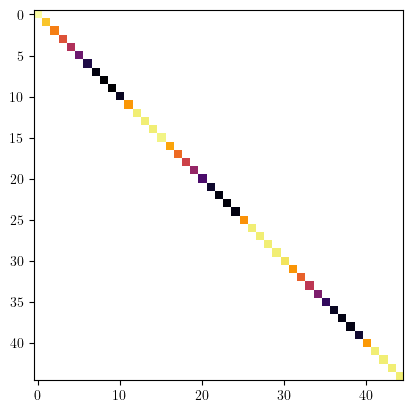

In [18]:
# cov_mat_all
# Pge_err_z0_wh
pl.figure()
pl.imshow(np.log(np.abs(cov_mat_all[nell_all:, nell_all:])), cmap='inferno')


In [19]:
bin_comb_all_wprobe[:19]



[['ky', [1, 0]],
 ['ky', [2, 0]],
 ['ky', [3, 0]],
 ['ky', [4, 0]],
 ['ky', [5, 0]],
 ['kk', [1, 1]],
 ['kk', [1, 2]],
 ['kk', [1, 3]],
 ['kk', [1, 4]],
 ['kk', [1, 5]],
 ['kk', [2, 2]],
 ['kk', [2, 3]],
 ['kk', [2, 4]],
 ['kk', [2, 5]],
 ['kk', [3, 3]],
 ['kk', [3, 4]],
 ['kk', [3, 5]],
 ['kk', [4, 4]],
 ['kk', [4, 5]]]

In [20]:
probe_boundaries = np.array([5,15,3,6, 15])
probe_boundaries_cs = np.cumsum(probe_boundaries)
probe_boundaries_center = probe_boundaries_cs - (probe_boundaries/2)
# print(probe_boundaries_cs)
probe_boundaries_edge_right = probe_boundaries_cs
probe_boundaries_edge_left = probe_boundaries_cs - probe_boundaries
ell_edge_left = nell*probe_boundaries_edge_left
ell_edge_right = nell*probe_boundaries_edge_right
probes_all.append('ge')
ell_edge_left = np.append(ell_edge_left, ell_edge_right[-1])
ell_edge_right = np.append(ell_edge_right, ell_edge_right[-1] + 3*nk)




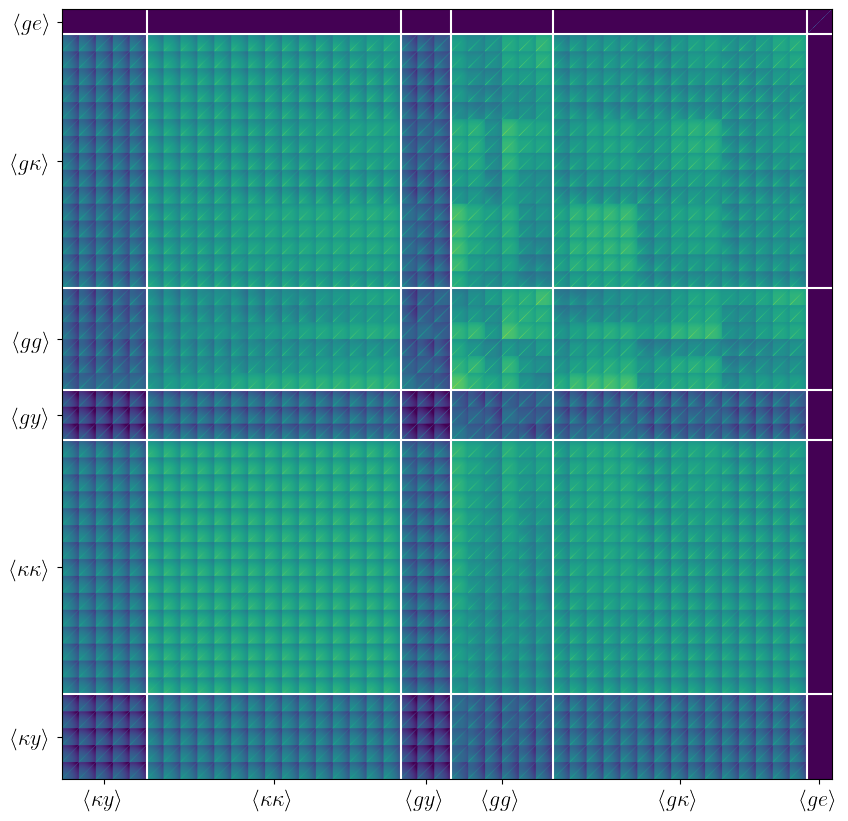

In [21]:
pl.figure(figsize=(10,10))
pl.imshow(np.log(np.abs(cov_mat_all + 1e-70)), origin='lower', vmin=-100, vmax=-20)
pl.axhline(probe_boundaries_cs[0]*nell, color='white')
pl.axhline(probe_boundaries_cs[1]*nell, color='white')
pl.axhline(probe_boundaries_cs[2]*nell, color='white')
pl.axhline(probe_boundaries_cs[3]*nell, color='white')
pl.axhline(probe_boundaries_cs[4]*nell, color='white')

pl.axvline(probe_boundaries_cs[0]*nell, color='white')
pl.axvline(probe_boundaries_cs[1]*nell, color='white')
pl.axvline(probe_boundaries_cs[2]*nell, color='white')
pl.axvline(probe_boundaries_cs[3]*nell, color='white')
pl.axvline(probe_boundaries_cs[4]*nell, color='white')

# write custom text as x-axis labels at a given tick values:
# pl.xticks(probe_boundaries_center*nell, ['ky', 'kk', 'gy', 'gg', 'gk'], fontsize=16)
ticks_loc = np.append(probe_boundaries_center*nell, [probe_boundaries_cs[-1]*nell + 1.5*nk])
pl.xticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
pl.yticks(ticks_loc, [r'$\langle \kappa y \rangle$', r'$\langle \kappa \kappa  \rangle$', r'$\langle g y \rangle$', r'$\langle gg \rangle$', r'$\langle g \kappa \rangle$', r'$\langle g e \rangle$'], fontsize=16)
# pl.imshow(cov_mat_all[1050:,1050:], origin='lower')
pl.savefig('cov_mat_all_new_v3.pdf', bbox_inches='tight', dpi=300)


In [22]:
from get_power_spectra import get_power_BCMP
get_power_test = get_power_BCMP(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)



In [23]:
Cl_all = np.zeros((nell_all + nbl*nk))
for jp1 in range(len(bin_comb_all_wprobe)):
    binwprobe1 = bin_comb_all_wprobe[jp1]
    probe1 = binwprobe1[0]
    bin_comb1 = binwprobe1[1]
    b1, b2 = bin_comb1[0], bin_comb1[1]
    Cl_all[jp1*nell:(jp1+1)*nell] = cov_test.Cl_result_dict[f'{probe1}'][f'bin_{b1}_{b2}']['tot_ellsurvey']

Cl_all[nell_all:nell_all+nk] = get_power_test.Pge_tot_mat[0,:]
Cl_all[nell_all+nk:nell_all+2*nk] = get_power_test.Pge_tot_mat[1,:]
Cl_all[nell_all+2*nk:nell_all+3*nk] = get_power_test.Pge_tot_mat[2,:]


In [24]:
# get_power_test.Pge_tot_array[2,:]
# Cl_all.shape, cov_mat_all.shape



In [25]:
# probes_all


In [26]:
# Cl_all.shape
# ell_edge_left, ell_edge_right
# nk
ks

array([ 0.05      ,  0.08189469,  0.13413479,  0.21969853,  0.35984284,
        0.58938432,  0.96534886,  1.58113883,  2.58973734,  4.24171449,
        6.94747747, 11.37922963, 18.6379686 , 30.52701148, 50.        ])

In [27]:
# save DV:
saved = {'ell_array':l_array_survey, 'k_array':analysis_dict['k_array_survey'], 
         'Cl_Pk':Cl_all, 'cov_mat':cov_mat_all, 'probes':probes_all, 
         'edges_left':ell_edge_left, 'edges_right':ell_edge_right,
         'bin_comb_all_wprobe':bin_comb_all_wprobe}
pk.dump(saved, open(abs_path_data + '/pge/DV_fid_Cl_Pk_cov_mthresh_hod_v3.pk','wb'))



(1300.0, 1400.0)

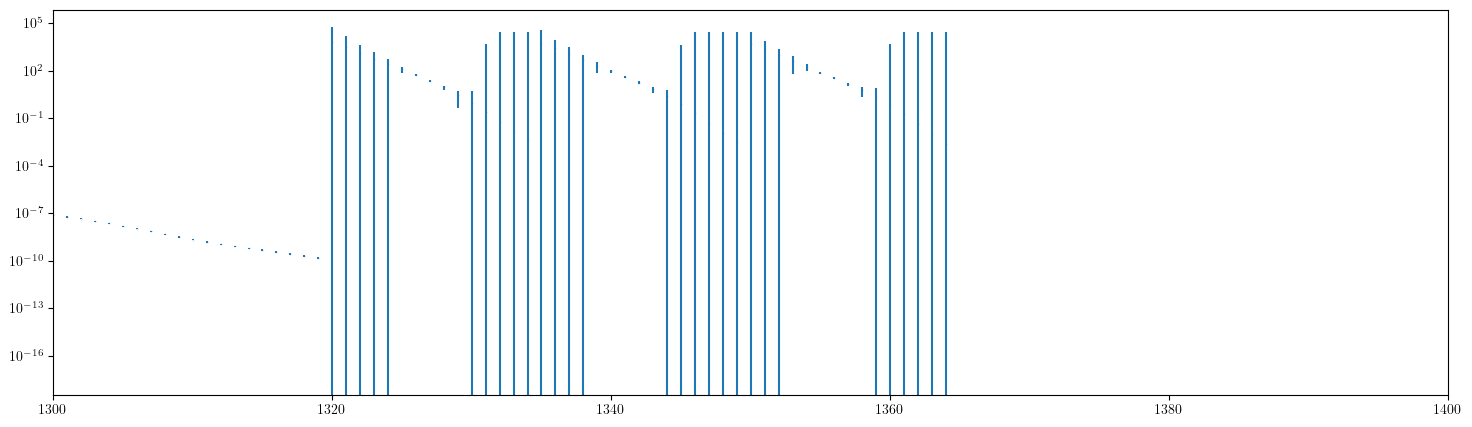

In [65]:
pl.figure(figsize=(18,5))
pl.errorbar(np.arange(nell_all + nbl*nk), Cl_all, yerr=np.sqrt(np.diag(cov_mat_all)), fmt='o', markersize=0.1)
pl.yscale('log')
pl.xlim(1300,1400)



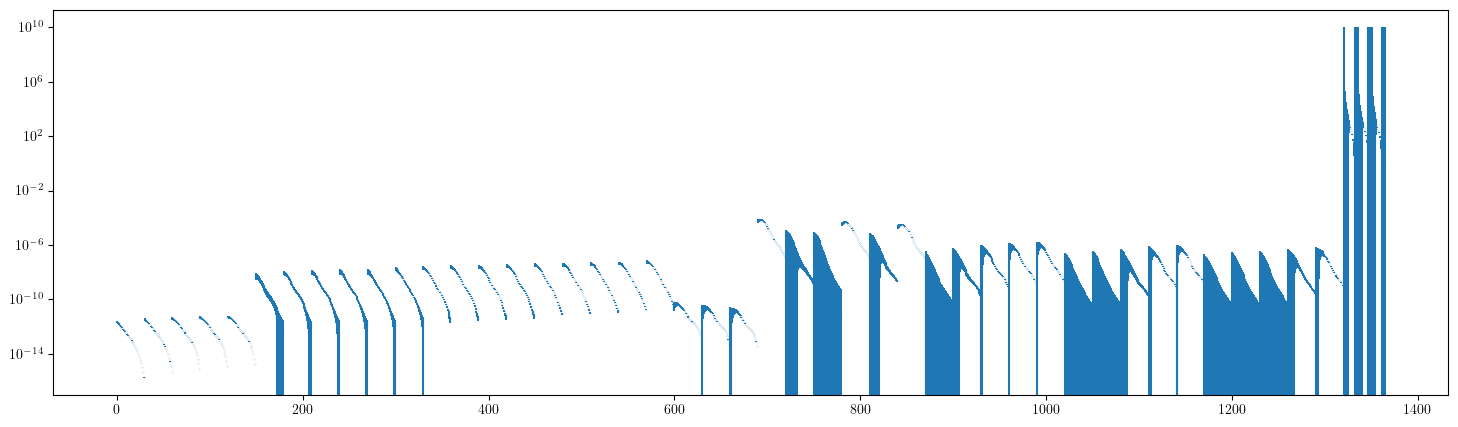

In [21]:
pl.figure(figsize=(18,5))
pl.errorbar(np.arange(nell_all + nbl*nk), Cl_all, yerr=np.sqrt(np.diag(cov_mat_all)), fmt='o', markersize=0.1)
pl.yscale('log')
# pl.xlim(1000,1200)



In [129]:
# cov_test.covtot_dict.keys()
cov_test.Cl_result_dict['gg']['bin_1_1'].keys()


dict_keys(['tot_ellsurvey', 'tot_plus_noise_ellsurvey'])

In [225]:
M_array = jnp.logspace(11, 16, 10)
val = 1e13
jnp.where(M_array > val, 1, 0)   


Array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=int64, weak_type=True)

In [227]:
(-1)**1.5

(-1.8369701987210297e-16-1j)

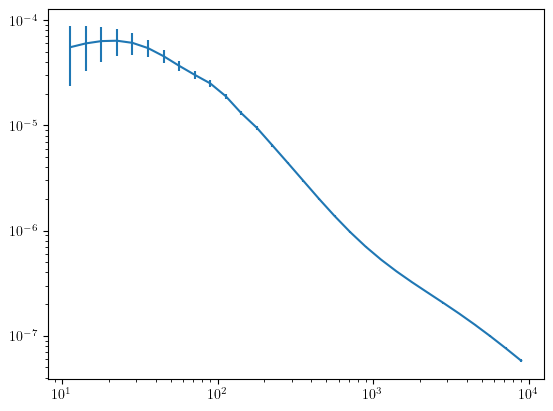

In [130]:
pl.figure()
pl.errorbar(cov_test.Cl_result_dict['l_array_survey'],cov_test.Cl_result_dict['gg']['bin_1_1']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gg_gg']['bin_1_1_1_1'])) )
pl.xscale('log')
pl.yscale('log')




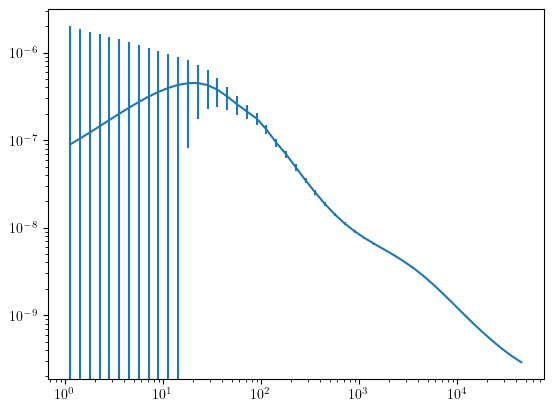

In [ ]:
pl.figure()
pl.errorbar(cov_test.Cl_result_dict['l_array_survey'],cov_test.Cl_result_dict['gk']['bin_1_3']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gk_gk']['bin_1_3_1_3'])) )
pl.xscale('log')
pl.yscale('log')




(1e-14, 1e-10)

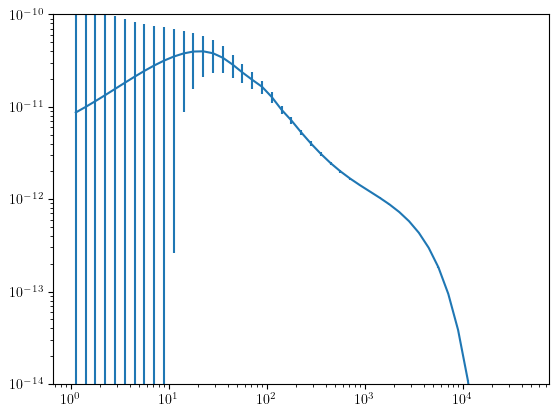

In [52]:
ell = cov_test.Cl_result_dict['l_array_survey']
pl.figure()
pl.errorbar(ell,cov_test.Cl_result_dict['gy']['bin_1_0']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['gy_gy']['bin_1_0_1_0'])) )
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-14, 1e-10)




(1e-18, 1e-11)

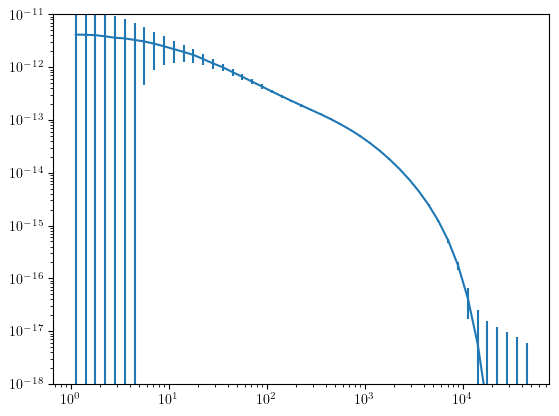

In [54]:
ell = cov_test.Cl_result_dict['l_array_survey']
pl.figure()
pl.errorbar(ell,cov_test.Cl_result_dict['ky']['bin_1_0']['tot_ellsurvey'],np.sqrt(np.diag(cov_test.covtot_dict['ky_ky']['bin_1_0_1_0'])) )
pl.xscale('log')
pl.yscale('log')
pl.ylim(1e-18, 1e-11)




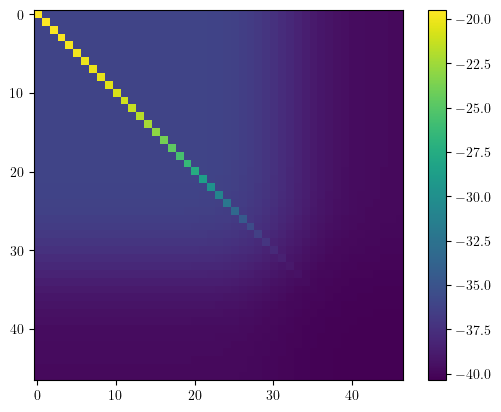

In [48]:
pl.figure()
pl.imshow(np.log(np.abs(cov_test.covtot_dict['gg_gg']['bin_1_1_1_1'])))
pl.colorbar()
pl.show()


